<a href="https://colab.research.google.com/github/Humak1/catshackathon/blob/fat-cats/calculate_accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the data (Colab), added by Huma
Upload `carbon_intensity_data.zip` and unzip it. Needed every Colab session. It creates the
`carbon_intensity_data` folder that `DATA_DIR` (next cell) points to.

In [ ]:
# I upload the zipped data folder and unzip it (needed every Colab session)
from google.colab import files
files.upload()                               # pick carbon_intensity_data.zip
!unzip -q -o carbon_intensity_data.zip
!ls carbon_intensity_data | head            # should list the region folders

Saving carbon_intensity_data.zip to carbon_intensity_data.zip
East_England
East_Midlands
London
North_East_England
North_Scotland
North_Wales_and_Merseyside
North_West_England
South_East_England
South_England
South_Scotland


In [ ]:
# I upload the zipped data folder (I need to do this every time the Colab session restarts)
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path("carbon_intensity_data")

In [ ]:
def load_and_clean_data():
    # I read every CSV (one folder per region, one file per forecast run) into one table.
    # don't do this, keep regions separate

    # The file name tells me the postcode and when the forecast was made, e.g. WC1E_2026-05-12T00:00:00+00:00.csv
    frames = []
    for f in sorted(DATA_DIR.glob("*/*.csv")):
        df = pd.read_csv(f)
        df["region"] = f.parent.name
        _, df["forecast_issued"] = f.stem.split("_", 1)
        frames.append(df)

    raw = pd.concat(frames, ignore_index=True)
    # I turn the text dates into real UTC timestamps
    raw["datetime"] = pd.to_datetime(raw["datetime"], utc=True, format="ISO8601")
    raw["forecast_issued"] = pd.to_datetime(raw["forecast_issued"], utc=True, format="ISO8601")

    # drop early data, it was very incomplete
    raw = raw[raw.forecast_issued >= "2026-04-08"]

    # how many hours ahead is each forecast?
    raw["horizon_h"] = (raw["datetime"] - raw["forecast_issued"]).dt.total_seconds() / 3600

    return raw

In [ ]:
def plot_timestep(data, timestamp):

    df = data[(data['datetime'] == timestamp)]

    fig, ax = plt.subplots(figsize=(10, 6))
    best = df

    # horrible way to get all the regions, lets refactor to index around them in the data structure
    regions = df.groupby("region").value.median().sort_values().index

    ax.boxplot([df.loc[df.region == r, "value"] for r in regions], vert=False, showfliers=False,
               tick_labels=[r.replace("_", " ") for r in regions])
    ax.set_xlabel("carbon intensity (gCO₂/kWh)")
    ax.set_title("Carbon intensity by region for one timestep")
    ax.grid()
    ax.set_xticks(np.linspace(0,399,20))
    plt.show()

    for region in regions:
        regional_data = df[df['region'] == region].value
        print(f"Region: {region} max: {regional_data.max()} min: {regional_data.min()} median: {regional_data.median()} lower quartile: {regional_data.quantile(0.25)} upper quartile: {regional_data.quantile(0.75)}")

In [ ]:
data = load_and_clean_data()

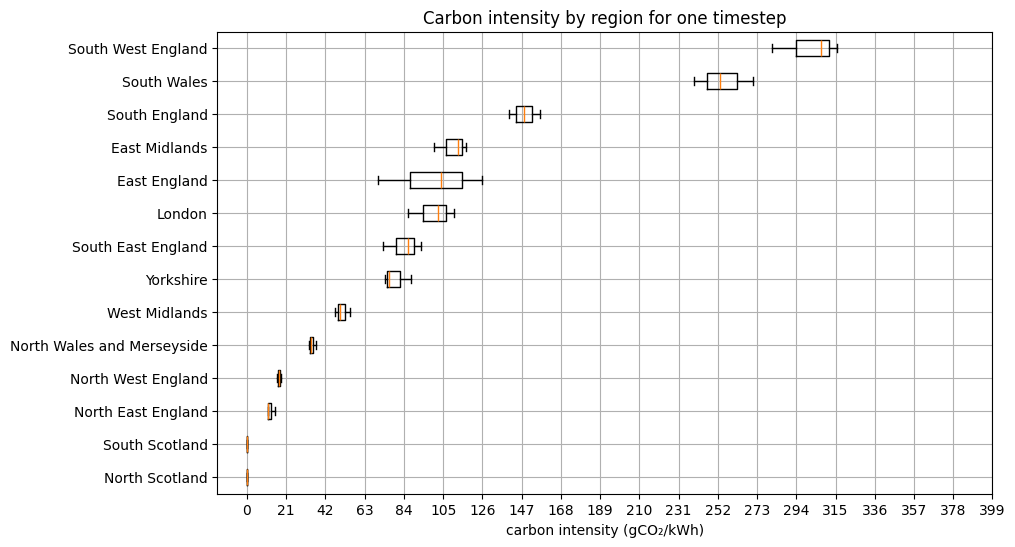

Region: North_Scotland max: 0 min: 0 median: 0.0 lower quartile: 0.0 upper quartile: 0.0
Region: South_Scotland max: 0 min: 0 median: 0.0 lower quartile: 0.0 upper quartile: 0.0
Region: North_East_England max: 15 min: 11 median: 11.0 lower quartile: 11.0 upper quartile: 13.0
Region: North_West_England max: 18 min: 16 median: 17.0 lower quartile: 16.5 upper quartile: 17.5
Region: North_Wales_and_Merseyside max: 37 min: 33 median: 34.0 lower quartile: 33.5 upper quartile: 35.5
Region: West_Midlands max: 55 min: 47 median: 50.0 lower quartile: 48.5 upper quartile: 52.5
Region: Yorkshire max: 88 min: 74 median: 76.0 lower quartile: 75.0 upper quartile: 82.0
Region: South_East_England max: 93 min: 73 median: 86.0 lower quartile: 79.5 upper quartile: 89.5
Region: London max: 111 min: 86 median: 102.0 lower quartile: 94.0 upper quartile: 106.5
Region: East_England max: 126 min: 70 median: 104.0 lower quartile: 87.0 upper quartile: 115.0
Region: East_Midlands max: 117 min: 100 median: 113.0 lo

In [ ]:
plot_timestep(data, "2026-09-03 20:00:00")

In [ ]:
# sanity checking
data[(data["datetime"] == "2026-09-02 20:00:00") & (data["region"] == "North_Scotland")]

,datetime,value,region,forecast_issued,horizon_h
313906,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-01 12:00:00+00:00,32.0
313990,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-01 18:00:00+00:00,26.0
314066,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-02 00:00:00+00:00,20.0
314130,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-02 06:00:00+00:00,14.0
314182,2026-09-02 20:00:00+00:00,0,North_Scotland,2026-09-02 12:00:00+00:00,8.0


In [ ]:
# for all (or most) datapoints we have 4 values for the same time from different forecasts
# each of these has a horizon_h which tells us its age
# we want to compare them
# use the one with the lowest horizon_h as the ground truth?
# plot abs difference of each value and ground_truth for all non-zero values of horizon_h

## Task 2: How much do forecasts change? (per region), added by Huma
For each region: I take the most recent forecast for every half-hour as the reference, calculate the
absolute difference between it and every older forecast, and average across all time points.
The cells above are unchanged.

### Step 1: Remove the frozen runs
26 runs (in all 14 regions) are exact copies of the previous run: the API stopped updating and the
same forecast was saved again. Here each copy would be compared with itself and give 0, making forecasts
look more stable than they are. Detected across all regions together, because Scotland is 0 so often it
would look "unchanged" on its own. `data` is unchanged; I work on `clean`.

In [18]:
def remove_frozen_runs(data):
    # compare every forecast with the one made just before it, for the same region and half-hour
    x = data.sort_values(["region", "datetime", "forecast_issued"])
    g = x.groupby(["region", "datetime"]).value
    x["same_as_before"] = g.diff().eq(0)
    x["has_earlier"] = g.cumcount() > 0
    # a run is frozen if 100% of its values are unchanged across all regions
    share_same = x[x.has_earlier].groupby("forecast_issued").same_as_before.mean()
    frozen = share_same[share_same == 1].index
    print(f"removing {len(frozen)} frozen runs")
    return data[~data.forecast_issued.isin(frozen)]

clean = remove_frozen_runs(data)
print(len(data), 'rows before,', len(clean), 'rows after')

removing 26 frozen runs
904474 rows before, 882578 rows after


**Result:** 26 frozen runs removed (21,896 rows). The North Scotland example above (5 forecasts for
2 Sep 20:00) had 4 frozen copies, so it really has 1 genuine forecast.

### Step 2: Analyse one region
- **Reference:** the most recent forecast for each half-hour (smallest `horizon_h`), used only if it
  was made < 6 h ahead. During gaps the "most recent" can be a day old, which is a poor reference.
- **Regular runs only** (00, 06, 12, 18 UTC). The two off-schedule runs on 8 April would add an odd
  extra band.
- The reference is still a forecast, not a measured value, so this measures **forecast revision**,
  not true accuracy.

In [ ]:
def analyse_region(data, region, max_ref_age_h=6):
    # one region, regular 6-hourly runs only
    df = data[(data.region == region) & data.forecast_issued.dt.hour.isin([0, 6, 12, 18])]
    df = df.sort_values(["datetime", "horizon_h"])

    # for each half-hour, the most recent forecast (smallest horizon_h) is the reference
    per_time = df.groupby("datetime")
    df = df.assign(ref=per_time.value.transform("first"),
                   ref_age_h=per_time.horizon_h.transform("first"))
    df = df[df.ref_age_h < max_ref_age_h]          # only use a reference made < 6 h ahead

    # absolute difference of every older forecast from the reference
    older = df[df.horizon_h > df.ref_age_h].copy()
    older["abs_diff"] = (older.value - older.ref).abs()
    older["lead"] = (older.horizon_h // 6 * 6).astype(int)   # 6-hour bands

    return {"mean abs diff (g)": older.abs_diff.mean(),
            "mean level (g)": df.drop_duplicates("datetime").ref.mean(),
            "n comparisons": len(older),
            "by lead (g)": older.groupby("lead").abs_diff.mean()}

analyse_region(clean, "London")

{'mean abs diff (g)': np.float64(25.85934471093542),
 'mean level (g)': np.float64(143.23931297709925),
 'n comparisons': 52618,
 'by lead (g)': lead
 6     22.565104
 12    25.374868
 18    26.828689
 24    26.564503
 30    26.814577
 36    26.408333
 42    26.556154
 Name: abs_diff, dtype: float64}

**Result (London):** older forecasts differ from the most recent one by **25.9 g on average**, about
18% of London's typical level (143 g). With the frozen runs left in it would be 25.2 g, because each
copy is compared with itself.

### Step 3: All regions
Shown in grams and as a % of each region's typical level, because 30 g matters more in a clean region
than a dirty one.

In [ ]:
results = {region: analyse_region(clean, region) for region in sorted(clean.region.unique())}

summary = pd.DataFrame({r: {k: v for k, v in res.items() if k != "by lead (g)"}
                        for r, res in results.items()}).T.astype(float)
summary["mean abs diff (% of level)"] = summary["mean abs diff (g)"] / summary["mean level (g)"] * 100
summary.round(1).sort_values("mean abs diff (g)")

,mean abs diff (g),mean level (g),n comparisons,mean abs diff (% of level)
North_Scotland,0.1,0.2,52786.0,75.2
South_Scotland,1.0,1.4,52786.0,71.0
North_East_England,3.6,15.5,52786.0,23.0
North_West_England,10.6,36.3,52786.0,29.2
Yorkshire,17.0,96.0,52462.0,17.7
North_Wales_and_Merseyside,24.5,61.9,52618.0,39.7
London,25.9,143.2,52618.0,18.1
East_Midlands,28.1,155.1,52462.0,18.1
West_Midlands,28.2,99.4,52462.0,28.3
South_England,29.2,153.6,52462.0,19.0


**Result:**
- **Largest in grams:** South Wales (35.6 g) and the South West (33.3 g), the two dirtiest regions.
- **Largest as a % of level:** North Wales & Merseyside (40%) and the North West (29%). These are
  the hardest to forecast relative to their size.
- **Smallest:** the North East (3.6 g) and Scotland (about 0–1 g). Scotland's % isn't meaningful,
  because its level is close to 0.

### Step 4: How the difference grows with lead time

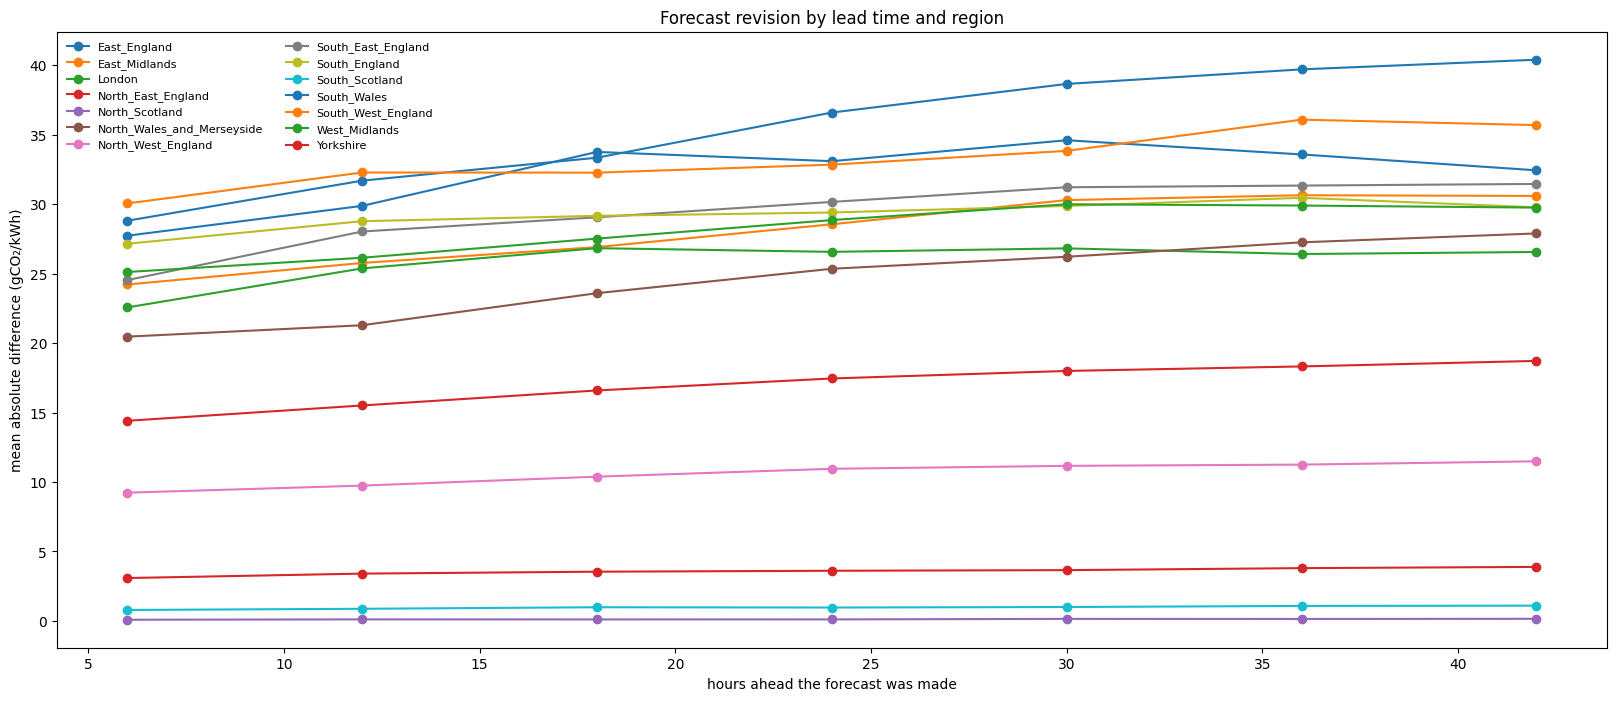

,East_England,East_Midlands,London,North_East_England,North_Scotland,North_Wales_and_Merseyside,North_West_England,South_East_England,South_England,South_Scotland,South_Wales,South_West_England,West_Midlands,Yorkshire
lead,,,,,,,,,,,,,,
6,27.7,24.2,22.6,3.1,0.1,20.5,9.2,24.5,27.1,0.8,28.8,30.0,25.1,14.4
12,29.9,25.8,25.4,3.4,0.1,21.3,9.7,28.0,28.8,0.9,31.7,32.3,26.1,15.5
18,33.8,26.9,26.8,3.5,0.1,23.6,10.4,29.1,29.2,1.0,33.3,32.3,27.5,16.6
24,33.1,28.6,26.6,3.6,0.1,25.3,10.9,30.2,29.4,1.0,36.6,32.8,28.9,17.5
30,34.6,30.3,26.8,3.7,0.1,26.2,11.2,31.2,29.9,1.0,38.7,33.8,30.0,18.0
36,33.6,30.6,26.4,3.8,0.1,27.2,11.2,31.3,30.5,1.1,39.7,36.1,29.9,18.3
42,32.4,30.6,26.6,3.9,0.2,27.9,11.5,31.5,29.8,1.1,40.4,35.7,29.8,18.7


In [ ]:
by_lead = pd.DataFrame({r: res["by lead (g)"] for r, res in results.items()})
ax = by_lead.plot(figsize=(20, 8), marker="o")
ax.set(xlabel="hours ahead the forecast was made", ylabel="mean absolute difference (gCO₂/kWh)",
       title="Forecast revision by lead time and region")
ax.legend(fontsize=8, ncol=2, frameon=False)
plt.show()
by_lead.round(1)

**Result:** differences grow with lead time, but most of the uncertainty is already there early on.

* London goes from 22.6 g (6 h ahead) to 26.6 g (42 h), so it's roughly flat after 18 h.

* South Wales keeps getting worse (28.8 → 40.4 g), so its long-range forecasts are the least reliable.



**Takeaway for CATS:** a day-ahead forecast is typically about 20–40 g away from the final one in
England and Wales. Scheduling decisions made a day ahead should allow for that margin.